# Predicting Airbnb Tokyo Price from Combined Text with mmBERT

`description` だけでなく、価格予測に有効と思われる複数のテキスト列をまとめたテキストから $\log(\mathrm{price})$ を予測する回帰モデルです。multilingual 版の mmBERT として `jhu-clsp/mmBERT-small` を Hugging Face `Trainer` で fine-tuning します。

## 基本情報

- 主題: mmBERT の Fine-tuning
- 作成者: 荒田禎之
- 位置づけ: 複数のテキスト情報から価格を予測する回帰モデルの構築
- 使用データ: Inside Airbnb Tokyo listings
- 分析課題: listing のテキスト情報から $\log(\mathrm{price})$ を予測
- 到達目標:
  - `description` 以外のテキスト情報も使った価格予測モデルを構築する
  - 複数列のテキストを1つの入力文として mmBERT に渡す方法を理解する

This notebook includes code and explanations generated with OpenAI Codex.


In [1]:
# 必要なライブラリが未インストールの場合のみ、次の行のコメントを外してください。
# %pip install -q -U transformers datasets accelerate scikit-learn

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

sns.set_theme(style="whitegrid")
SEED = 42


## 1. データの読み込み

Inside Airbnb Tokyo の listings URL から直接読み込む。

今回の入力候補は、listing の内容、立地、ホスト情報、設備を表しやすい以下のテキスト列である。

- `name`
- `description`
- `neighborhood_overview`
- `host_about`
- `amenities`

これらのうち、データに存在する列を結合して1つの `text` を作る。


In [ ]:
DATA_URL = "https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/2026-06-30/data/listings.csv.gz"
filename = "airbnb_tokyo_model_ready_eda.csv"
candidate_paths = [Path(filename), Path("data") / filename, Path("notebook") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

price_cols = ["price", "price_num"]
text_cols = [
    "name",
    "description",
    "neighborhood_overview",
    "host_about",
    "amenities",
]
filter_cols = ["number_of_reviews"]
required_raw_cols = set(text_cols + ["price"] + filter_cols)
min_text_cols_for_local = {"description", "name", "neighborhood_overview"}

if csv_path is not None:
    local_df = pd.read_csv(csv_path)
    local_text_cols = [col for col in text_cols if col in local_df.columns]
    has_price = "price_num" in local_df.columns or "price" in local_df.columns
    has_filter_cols = set(filter_cols).issubset(local_df.columns)
    if has_price and has_filter_cols and min_text_cols_for_local.issubset(local_df.columns):
        df = local_df
        print(f"Loaded local modeling data: {csv_path.resolve()}")
    else:
        print("Local file found, but it does not contain enough text columns for this notebook.")
        print(f"Local text columns found: {local_text_cols}")
        print(f"Local filter columns found: {[col for col in filter_cols if col in local_df.columns]}")
        df = pd.read_csv(
            DATA_URL,
            compression="gzip",
            low_memory=False,
            usecols=lambda col: col in required_raw_cols,
        )
        print(f"Loaded Inside Airbnb data from: {DATA_URL}")
else:
    df = pd.read_csv(
        DATA_URL,
        compression="gzip",
        low_memory=False,
        usecols=lambda col: col in required_raw_cols,
    )
    print(f"Loaded Inside Airbnb data from: {DATA_URL}")

rows_before = len(df)
available_text_cols = [col for col in text_cols if col in df.columns]
print(f"Original rows: {rows_before:,}")
print(f"Available text columns: {available_text_cols}")
display(df.head())


## 2. 複数テキスト列の結合と目的変数の作成

`price_num` があればそれを使い、ない場合は `price` から数値を作る。価格が欠損または非正の行、`number_of_reviews` が5未満の行、利用可能なテキストがすべて空の行を除外する。さらに、`number_of_reviews >= 5` を満たすサンプル内で価格の下位0.1%と上位0.1%を外れ値として除外する。

テキスト列は、列名の意味がモデルへ伝わるように `Name: ...`、`Description: ...` のようなラベル付きの短いブロックとして結合する。目的変数は $\log(\mathrm{price})$ とする。


In [ ]:
def clean_price(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    x = re.sub(r"[^0-9.]", "", str(x))
    return float(x) if x else np.nan


def clean_text_value(x):
    if pd.isna(x):
        return ""
    text = str(x)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_listing_text(row):
    labels = {
        "name": "Name",
        "description": "Description",
        "neighborhood_overview": "Neighborhood",
        "host_about": "Host",
        "amenities": "Amenities",
    }
    parts = []
    for col in available_text_cols:
        value = clean_text_value(row[col])
        if value:
            parts.append(f"{labels.get(col, col)}: {value}")
    return "\n".join(parts)


if "price_num" not in df.columns:
    if "price" not in df.columns:
        raise KeyError("`price_num` または `price` が必要です。")
    df["price_num"] = df["price"].apply(clean_price)

if not available_text_cols:
    raise KeyError("利用可能なテキスト列がありません。")
if "number_of_reviews" not in df.columns:
    raise KeyError("`number_of_reviews` が必要です。")

df["number_of_reviews"] = pd.to_numeric(df["number_of_reviews"], errors="coerce")

base_mask = (
    df["price_num"].notna()
    & (df["price_num"] > 0)
    & df["number_of_reviews"].notna()
    & (df["number_of_reviews"] >= 5)
)
price_lower = df.loc[base_mask, "price_num"].quantile(0.001)
price_upper = df.loc[base_mask, "price_num"].quantile(0.999)
sample_mask = base_mask & df["price_num"].between(price_lower, price_upper)

print(f"Rows with positive price and number_of_reviews >= 5: {base_mask.sum():,}")
print(f"Price filter: {price_lower:,.0f} <= price_num <= {price_upper:,.0f}")
print(f"Rows after price 0.1% tail filtering: {sample_mask.sum():,}")

model_data = df.loc[
    sample_mask,
    available_text_cols + ["price_num", "number_of_reviews"],
].copy()
model_data["text"] = model_data.apply(build_listing_text, axis=1)
model_data = (
    model_data.loc[model_data["text"].str.strip().ne("")]
    .drop_duplicates(subset=["text"])
    .reset_index(drop=True)
)
model_data["label"] = np.log(model_data["price_num"]).astype("float32")

print(f"Rows used after filtering and deduplication: {len(model_data):,}")
display(model_data[["text", "price_num", "number_of_reviews", "label"]].head())
display(model_data["label"].describe().rename("log_price").to_frame())


### 結合テキストの長さ

複数のテキスト列を結合するため、`description` 単独より入力が長くなりやすい。文字数の分布を確認し、`MAX_LENGTH` による切り詰めの影響を把握する。


,combined_text_length
count,22903.000000
mean,1417.837139
std,418.657633
min,169.000000
50%,1388.000000
75%,1654.000000
90%,1944.000000
95%,2130.000000
99%,2566.000000
max,5539.000000


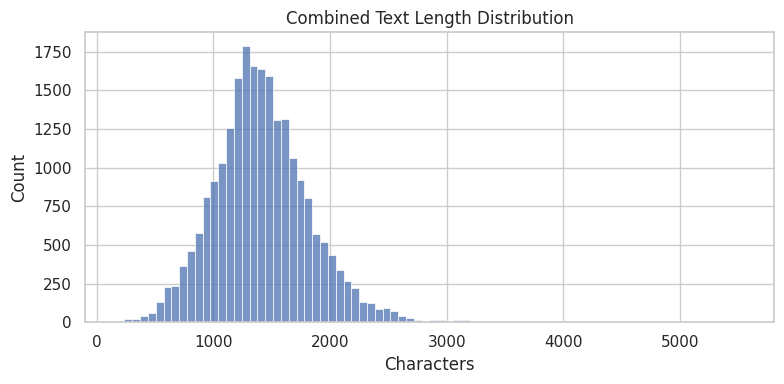

In [4]:
text_length = model_data["text"].str.len()
length_summary = text_length.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).rename("combined_text_length")
display(length_summary.to_frame())

plt.figure(figsize=(8, 4))
sns.histplot(text_length, bins=80)
plt.title("Combined Text Length Distribution")
plt.xlabel("Characters")
plt.tight_layout()
plt.show()


## 3. mmBERT の準備とデータ分割

80%を訓練、10%を検証、10%を最終テストに使う。動作確認だけを短時間で行いたい場合は `MAX_ROWS` に行数を指定する。

複数テキスト列を結合すると入力が長くなるため、`MAX_LENGTH` は `airbnb_mmBERT.ipynb` より少し長い 384 にしている。GPU メモリが不足する場合は 256 に下げる。


In [5]:
MODEL_NAME = "jhu-clsp/mmBERT-small"
MAX_LENGTH = 384
MAX_ROWS = 10_000  # 全データを使う場合は None

if MAX_ROWS is not None and len(model_data) > MAX_ROWS:
    model_data = model_data.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)

print(f"Model: {MODEL_NAME}")
print(f"Rows used for fine-tuning: {len(model_data):,}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="regression",
)

dataset = Dataset.from_pandas(
    model_data[["text", "label"]], preserve_index=False
)
train_holdout = dataset.train_test_split(test_size=0.2, seed=SEED)
valid_test = train_holdout["test"].train_test_split(test_size=0.5, seed=SEED)
dataset = DatasetDict({
    "train": train_holdout["train"],
    "validation": valid_test["train"],
    "test": valid_test["test"],
})

print(dataset)


Model: jhu-clsp/mmBERT-small
Rows used for fine-tuning: 10,000


config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/564M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-small
Key               | Status     | 
------------------+------------+-
decoder.weight    | UNEXPECTED | 
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
})


## 4. Tokenization

結合済みの listing text を mmBERT の tokenizer でトークン化する。`MAX_LENGTH=384` は文字数ではなく特殊トークンを含む最大トークン数であり、超過部分は末尾から切り詰める。padding は `Trainer` が batch 作成時に行う。


In [6]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)
tokenized_dataset


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1000
    })
})

## 5. 評価指標

学習時の損失と RMSE・MAE・$R^2$ は log 価格で計算する。参考として、価格に戻した MAE も計算する。


In [7]:
def compute_metrics(eval_prediction):
    predictions = np.asarray(eval_prediction.predictions).reshape(-1)
    labels = np.asarray(eval_prediction.label_ids).reshape(-1)
    return {
        "rmse": mean_squared_error(labels, predictions) ** 0.5,
        "mae": mean_absolute_error(labels, predictions),
        "r2": r2_score(labels, predictions),
        "price_mae_jpy": mean_absolute_error(
            np.exp(labels), np.exp(predictions)
        ),
    }


## 6. Fine-tuning

GPU が利用可能な場合は mixed precision (`fp16`) を有効にする。検証 RMSE が改善しない状態が2 epoch続いた場合は学習を停止し、最良モデルを復元する。


In [8]:
training_args = TrainingArguments(
    output_dir="./airbnb-mmbert-combined-text",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Rmse,Mae,R2,Price Mae Jpy
1,1.599446,0.314178,0.560516,0.443058,0.184979,10863.792969
2,1.195900,0.294631,0.542799,0.421441,0.235688,10503.721680
3,0.930618,0.220687,0.469774,0.363656,0.427507,9613.578125
4,0.707937,0.177752,0.421607,0.323257,0.538886,8664.732422
5,0.588342,0.164100,0.405093,0.307913,0.574302,8130.331543
6,0.425585,0.161902,0.402370,0.302292,0.580005,8256.077148
7,0.250801,0.159022,0.398775,0.296666,0.587476,7942.663574
8,0.196628,0.161496,0.401866,0.299523,0.581057,8523.803711
9,0.146523,0.156418,0.395497,0.290387,0.594231,8077.543945
10,0.094333,0.154538,0.393113,0.286402,0.599107,7952.463867


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2500, training_loss=6.771492363357544, metrics={'train_runtime': 2351.4913, 'train_samples_per_second': 34.021, 'train_steps_per_second': 1.063, 'total_flos': 7803182995924464.0, 'train_loss': 6.771492363357544, 'epoch': 10.0})

## 7. テストデータでの最終評価

学習や early stopping に使っていないテスト Dataset を、最良モデルで評価する。`metric_key_prefix="test"` により、loss、RMSE、MAE、$R^2$、円価格 MAE などへ `test_` 接頭辞を付け、表形式で表示する。


In [9]:
test_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test",
)
display(pd.Series(test_metrics, name="value").to_frame())


[transformers] early stopping required metric_for_best_model, but did not find eval_rmse so early stopping is disabled


Training Loss,Validation Loss,Epoch,Rmse,Mae,R2,Price Mae Jpy
0.094333,0.172840,10,0.415740,0.287678,0.554675,8755.410156


,value
test_loss,0.172840
test_rmse,0.415740
test_mae,0.287678
test_r2,0.554675
test_price_mae_jpy,8755.410156


### 予測値と残差の可視化

テストデータ全件の予測を取得し、実際の log 価格、予測 log 価格、残差を作る。左図は実測値と予測値を45度線と比較し、右図は「実際値 − 予測値」の分布を表示する。


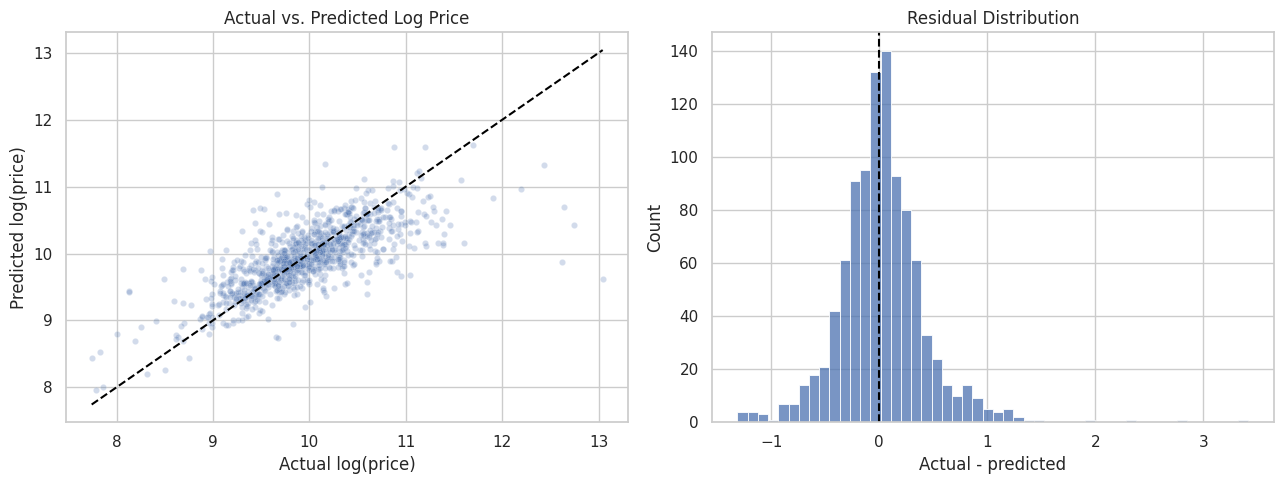

In [10]:
test_output = trainer.predict(tokenized_dataset["test"])
actual_log_price = np.asarray(test_output.label_ids).reshape(-1)
predicted_log_price = np.asarray(test_output.predictions).reshape(-1)
residuals = actual_log_price - predicted_log_price

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    x=actual_log_price,
    y=predicted_log_price,
    alpha=0.25,
    s=20,
    ax=axes[0],
)
limits = [
    min(actual_log_price.min(), predicted_log_price.min()),
    max(actual_log_price.max(), predicted_log_price.max()),
]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()


## 8. 新しい listing 情報から価格を予測

任意の listing 情報を辞書で渡し、学習時と同じ形式の結合テキストにして推論する関数を定義する。予測した log 価格と、それを指数変換した価格を返す。


In [11]:
def make_text_from_listing(listing):
    labels = {
        "name": "Name",
        "description": "Description",
        "neighborhood_overview": "Neighborhood",
        "host_about": "Host",
        "amenities": "Amenities",
    }
    parts = []
    for col in text_cols:
        value = clean_text_value(listing.get(col, ""))
        if value:
            parts.append(f"{labels.get(col, col)}: {value}")
    return "\n".join(parts)


def predict_price_from_listing_text(listing):
    text = make_text_from_listing(listing)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(model.device)
    model.eval()
    with torch.no_grad():
        predicted_log_price = model(**inputs).logits.squeeze().item()
    return {
        "text": text,
        "log_price": predicted_log_price,
        "price_jpy": float(np.exp(predicted_log_price)),
    }


example_listing = {
    "name": "Private apartment near Shinjuku Station",
    "description": "A bright private apartment with fast Wi-Fi, compact kitchen, and washing machine.",
    "neighborhood_overview": "Convenient area with restaurants, convenience stores, and easy train access.",
    "host_about": "Experienced local host who responds quickly to guest questions.",
    "amenities": "Wifi, Kitchen, Washer, Air conditioning, Elevator",
}
print(predict_price_from_listing_text(example_listing))


{'text': 'Name: Private apartment near Shinjuku Station\nDescription: A bright private apartment with fast Wi-Fi, compact kitchen, and washing machine.\nNeighborhood: Convenient area with restaurants, convenience stores, and easy train access.\nHost: Experienced local host who responds quickly to guest questions.\nAmenities: Wifi, Kitchen, Washer, Air conditioning, Elevator', 'log_price': 9.4375, 'price_jpy': 12550.301899404027}
